Project Overview:

My goal here is to simulate the 2026 World Cup. I love soccer and am increasingly excited about this years World Cup considering it is being hosted in my home country. My goal is to build a model that predicts match results then use that model to predict every match of the tournament. Once that is complete then run the simulation numerous times to understand who has the best chance of winninng. Finally, visualize said results.

In [133]:
import pandas as pd
import numpy as np


matches = pd.read_csv("/Users/tylerpailthorp/Desktop/World Cup Project/results.csv") 
old_rank = pd.read_csv("/Users/tylerpailthorp/Desktop/World Cup Project/fifa_mens_rank.csv")
rank_update = pd.read_csv(
    "/Users/tylerpailthorp/Desktop/World Cup Project/fifa_rankings_2025_2026_year_only.csv",
    encoding="latin1")

rank = pd.concat([old_rank, rank_update], ignore_index=True)


rank = rank.sort_values(["team", "date"]).reset_index(drop=True)

# recompute diff.points if needed
rank["previous.points"] = rank.groupby("team")["total.points"].shift(1)
rank["diff.points"] = rank["total.points"] - rank["previous.points"]




Data Cleaning and Merging:
 filtering by more recent matches as well as fixing any issues that may arise between each dataset.

In [134]:
matches['date'] = pd.to_datetime(matches['date']) ##Converting column to date time
matches = matches[matches['date'].dt.year >= 2010] #Filtering to matches after 2004

#Ensure all team names are similar
team_map = {
    "USA": "United States",
    "IR Iran": "Iran",
    "South Korea": "Korea Republic",
    "Cabo Verde": "Cape Verde",  
    "Côte d'Ivoire": "Ivory Coast",  
    "Czechia": "Czech Republic",
    "DR Congo": "Congo DR",
}

matches['home_team'] = matches['home_team'].replace(team_map)
matches['away_team'] = matches['away_team'].replace(team_map)
rank['team'] = rank['team'].replace(team_map)




rank['date'] = pd.to_datetime(rank['date'].astype(str) + '-01-01')
rank.loc[rank['semester'] == 2, 'date'] = rank['date'] + pd.DateOffset(months=6)

matches["date"] = pd.to_datetime(matches["date"]).dt.tz_localize(None)
rank["date"] = pd.to_datetime(rank["date"]).dt.tz_localize(None)

In [135]:
matches = matches.sort_values('date')
rank = rank.sort_values('date')

matches = pd.merge_asof(
    matches,
    rank.add_prefix('home_'),
    left_on='date',
    right_on='home_date',
    left_by='home_team',
    right_by='home_team',
    direction='backward'
)
matches = pd.merge_asof(
    matches,
    rank.add_prefix('away_'),
    left_on='date',
    right_on='away_date',
    left_by='away_team',
    right_by='away_team',
    direction='backward'
)




In [136]:
final = matches.drop(columns=[
    "home_date", "away_date",
    "home_semester", "away_semester",
    "home_acronym","away_acronym"
])

Feature Engineering:
Creating three different features for my mdoel based on the data I have access to


In [137]:
def result(row):
    if row["home_score"] > row['away_score']:
        return 1
    elif row["away_score"] > row['home_score']:
        return 0
    else:
        return 2

final["target"] = final.apply(result,axis =1)

final["rank_diff"] = final["home_rank"] - final["away_rank"]
final["points_diff"] = final["home_total.points"] - final["away_total.points"]
final["momentum_diff"] = final["home_diff.points"] - final["away_diff.points"]

In [138]:
features = [
    "rank_diff",
    "points_diff",
    "momentum_diff"
]
final = final.dropna(subset=features + ["target"])

X = final[features]
y = final["target"]


Model training:
Building my logistic regression model to predict match results from my historic dataset

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.dummy import DummyClassifier



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

match_pred_model = LogisticRegression(max_iter=1000)
match_pred_model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

preds = match_pred_model.predict(X_test)
print(accuracy_score(y_test, preds))

0.5989884393063584


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

In [140]:


print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))


dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print(dummy.score(X_test, y_test))


[[ 508  280    0]
 [ 156 1150    0]
 [ 244  430    0]]
              precision    recall  f1-score   support

           0       0.56      0.64      0.60       788
           1       0.62      0.88      0.73      1306
           2       0.00      0.00      0.00       674

    accuracy                           0.60      2768
   macro avg       0.39      0.51      0.44      2768
weighted avg       0.45      0.60      0.51      2768

0.4718208092485549


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

Model interpretation:
My first model itteration perfromed well. Achieving 60% accuarcy compared to the baseline of 47%. However, looking at the Confusion Matrix we see that my model predicts no draws which is unrealistic to the game of soccer and needs to be fixed.

Therefore, I need to update my model to focus on class imbalance and make my model more realisitc.

In [141]:
model_balance = LogisticRegression(max_iter=1000, class_weight="balanced")
model_balance.fit(X_train, y_train)

preds = model_balance.predict(X_test)
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

0.5567196531791907
              precision    recall  f1-score   support

           0       0.57      0.61      0.59       788
           1       0.73      0.63      0.68      1306
           2       0.30      0.36      0.33       674

    accuracy                           0.56      2768
   macro avg       0.53      0.53      0.53      2768
weighted avg       0.58      0.56      0.57      2768



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

Updated Model interpretation:

The new model accuracy score falls to 57%. However, it becomes more realistic as it is now prediciting draws.
Still outpreforms the baseline as well this time by around 10 percentage points.

2026 World Cup setup:
Time to start loading in the World Cup Match data as well as World Cup Team data.

In [142]:

#loading in World Cup 2026 data

teams = pd.read_csv("/Users/tylerpailthorp/Desktop/World Cup Project/teams_updated.csv")
WC_matches = pd.read_csv("/Users/tylerpailthorp/Desktop/World Cup Project/matches.csv")



WC_matches["home_team_id"] = WC_matches["home_team_id"].astype("Int64")
WC_matches["away_team_id"] = WC_matches["away_team_id"].astype("Int64")
teams["id"] = teams["id"].astype("Int64")

#Merging the two data sets, so team names allign

team_lookup = teams[["id", "team_name", "fifa_code", "group_letter", "is_placeholder"]]

home_lookup = teams[["id", "team_name", "fifa_code", "group_letter", "is_placeholder"]].rename(columns=
{
    "id": "home_team_id",
    "team_name": "home_team_name",
    "fifa_code": "home_fifa_code",
    "group_letter": "home_group_letter",
    "is_placeholder": "home_is_placeholder"
})

away_lookup = teams[["id", "team_name", "fifa_code", "group_letter", "is_placeholder"]].rename(columns=
{
    "id": "away_team_id",
    "team_name": "away_team_name",
    "fifa_code": "away_fifa_code",
    "group_letter": "away_group_letter",
    "is_placeholder": "away_is_placeholder"
})

WC_matches = WC_matches.merge(home_lookup, on="home_team_id", how="left")
WC_matches = WC_matches.merge(away_lookup, on="away_team_id", how="left")

WC_matches['home_team_name'] = WC_matches['home_team_name'].replace(team_map)
WC_matches['away_team_name'] = WC_matches['away_team_name'].replace(team_map)



In [143]:

team_stats = (
    rank.sort_values(["team", "date"])
        .groupby("team")
        .tail(1)
        .set_index("team")
)

def build_features(team1, team2):
    t1 = team_stats.loc[team1]
    t2 = team_stats.loc[team2]

    return pd.DataFrame([{
        "rank_diff": t1["rank"] - t2["rank"],
        "points_diff": t1["total.points"] - t2["total.points"],
        "momentum_diff": t1["diff.points"] - t2["diff.points"],
    }])

Simulating one match:
I want to see how this would work in action before simulating the entire tournament. So I used the model on the first match of the tournament


In [144]:

row = WC_matches.iloc[0]

team1 = row["home_team_name"]
team2 = row["away_team_name"]

X_match = build_features(team1, team2)

probs = model_balance.predict_proba(X_match)[0]

print(team1, "vs", team2)
print(probs)

result = np.random.choice([0,1,2], p=probs)
print(result)

def simulate_match(team1, team2):
    X = build_features(team1, team2)
    probs = model_balance.predict_proba(X)[0]
    result = np.random.choice([0,1,2], p=probs)
    return result


Mexico vs South Africa
[0.10063043 0.56503227 0.3343373 ]
1


Simulating Group Stage:
Now that my logic works for simulating a match I need to similate the group stage. Ensuring the logic of how teams gained points was accurate and making sure it can simulate an entire group.

In [145]:

def simulate_group(group_df):
    teams = set(group_df["home_team_name"]).union(set(group_df["away_team_name"]))
    
    # initialize standings
    table = {team: 0 for team in teams}
    
    for _, row in group_df.iterrows():
        t1 = row["home_team_name"]
        t2 = row["away_team_name"]
        
        result = simulate_match(t1, t2)
        
        if result == 1:  # home win
            table[t1] += 3
        elif result == 0:  # away win
            table[t2] += 3
        else:  # draw
            table[t1] += 1
            table[t2] += 1
      
    return sorted(table.items(), key=lambda x: (x[1], np.random.random()), reverse=True)

group_A = WC_matches[WC_matches["home_group_letter"] == "A"]
standings = simulate_group(group_A)

for team, points in standings:
    print(f"{team}: {points}")



Czech Republic: 7
South Africa: 5
Mexico: 2
Korea Republic: 1


In [146]:

group_results = {}
third_place_canidates =[]

for g in sorted(WC_matches["home_group_letter"].dropna().astype(str).unique()):
    group_df = WC_matches[WC_matches["home_group_letter"] == g]
    standings = simulate_group(group_df)

    group_results[g] = {
        "winner": standings[0][0],
        "runner_up": standings[1][0],
        "third_place": standings[2][0],
        "standings":standings
    }
    third_place_canidates.append({
    "group":g,
    "team": standings[2][0],
    "points": standings[2][1]
    })

Knockout Stage:
Focusing on the bracket setup to ensure simulations were as realistic as possible.
Needed to focus on third place logic, and ultimately simulate the knockouts.

In [147]:
##Creating a knockout stage. Using real life logic and realism of how the knockouts would actually play out

round_of_32_slots = [
    ("A", "runner_up", "B", "runner_up"),
    ("C", "winner",    "F", "runner_up"),
    ("E", "winner",    "third_place", ["A", "B", "C", "D", "F"]),
    ("F", "winner",    "C", "runner_up"),
    ("E", "runner_up", "I", "runner_up"),
    ("I", "winner",    "third_place", ["C", "D", "F", "G", "H"]),
    ("A", "winner",    "third_place", ["C", "E", "F", "H", "I"]),
    ("L", "winner",    "third_place", ["E", "H", "I", "J", "K"]),
    ("G", "winner",    "third_place", ["A", "E", "H", "I", "J"]),
    ("D", "winner",    "third_place", ["B", "E", "F", "I", "J"]),
    ("H", "winner",    "J", "runner_up"),
    ("K", "runner_up", "L", "runner_up"),
    ("B", "winner",    "third_place", ["E", "F", "G", "I", "J"]),
    ("D", "runner_up", "G", "runner_up"),
    ("J", "winner",    "H", "runner_up"),
    ("K", "winner",    "third_place", ["D", "E", "I", "J", "L"]),
]

best_thirds = sorted(third_place_canidates, key=lambda x: x["points"], reverse=True)[:8]

def get_team(group, position):
    if position in ["winner","runner_up","third_place"]:
        return group_results[group][position]
    return None

# Identify which slots need third-place teams
third_slots = [
    (i, slot[3]) 
    for i, slot in enumerate(round_of_32_slots)
    if slot[2] == "third_place"
]

def assign_thirds(slots, candidates):
    if not slots:
        return {}

    idx, eligible_groups = slots[0]

    for i, cand in enumerate(candidates):
        if cand["group"] in eligible_groups:
            remaining = candidates[:i] + candidates[i+1:]
            result = assign_thirds(slots[1:], remaining)
            if result is not None:
                result[idx] = cand["team"]
                return result

    return None

third_assignment = assign_thirds(third_slots, best_thirds.copy())

    


In [148]:

def build_round_of_32(round_of_32_slots, third_assignment):
    bracket = []

    for i, slot in enumerate(round_of_32_slots):

        if slot[2] == "third_place":
            g1, pos1, _, _ = slot
            team1 = get_team(g1, pos1)
            team2 = third_assignment[i]

        else:
            g1, pos1, g2, pos2 = slot
            team1 = get_team(g1, pos1)
            team2 = get_team(g2, pos2)

        bracket.append((team1, team2))

    return bracket


round_of_32 = build_round_of_32(round_of_32_slots, third_assignment)

for t1, t2 in round_of_32:
    print(t1, "vs", t2)


Czech Republic vs Canada
Morocco vs Japan
Germany vs Netherlands
Sweden vs Brazil
Ecuador vs Iraq
Senegal vs Turkey
Korea Republic vs Scotland
Panama vs France
Belgium vs Uruguay
United States vs Ivory Coast
Spain vs Algeria
Congo DR vs England
Switzerland vs Egypt
Paraguay vs Iran
Argentina vs Saudi Arabia
Portugal vs Croatia


In [149]:
def simulate_knockout_match(team1, team2):
    while True:
        X = build_features(team1, team2)
        probs = model_balance.predict_proba(X)[0]
        result = np.random.choice([0, 1, 2], p=probs)

        if result == 1:
            return team1
        elif result == 0:
            return team2
        



def simulate_round_with_print(pairings, round_name):
    winners = []
    print(f"\n=== {round_name} ===")

    for i, (team1, team2) in enumerate(pairings, start=1):
        winner = simulate_knockout_match(team1, team2)
        print(f"Match {i}: {team1} vs {team2} → {winner} Advances!")
        winners.append(winner)

    return winners

def simulate_full_knockout(round_of_32):

    # Round of 32
    r16 = simulate_round_with_print(round_of_32, "Round of 32")

    # Round of 16
    r16_pairs = list(zip(r16[::2], r16[1::2]))
    qf = simulate_round_with_print(r16_pairs, "Round of 16")

    # Quarterfinals
    qf_pairs = list(zip(qf[::2], qf[1::2]))
    sf = simulate_round_with_print(qf_pairs, "Quarterfinals")

    # Semifinals
    sf_pairs = list(zip(sf[::2], sf[1::2]))
    final_teams = simulate_round_with_print(sf_pairs, "Semifinals")

    # Final
    print("\n=== Final ===")
    champion = simulate_knockout_match(final_teams[0], final_teams[1])
    print(f"{final_teams[0]} vs {final_teams[1]} →  {champion} are the 2026 World Cup Winners!")

    return champion

champion = simulate_full_knockout(round_of_32)


=== Round of 32 ===
Match 1: Czech Republic vs Canada → Canada Advances!
Match 2: Morocco vs Japan → Morocco Advances!
Match 3: Germany vs Netherlands → Netherlands Advances!
Match 4: Sweden vs Brazil → Sweden Advances!
Match 5: Ecuador vs Iraq → Ecuador Advances!
Match 6: Senegal vs Turkey → Senegal Advances!
Match 7: Korea Republic vs Scotland → Scotland Advances!
Match 8: Panama vs France → France Advances!
Match 9: Belgium vs Uruguay → Uruguay Advances!
Match 10: United States vs Ivory Coast → United States Advances!
Match 11: Spain vs Algeria → Spain Advances!
Match 12: Congo DR vs England → England Advances!
Match 13: Switzerland vs Egypt → Egypt Advances!
Match 14: Paraguay vs Iran → Iran Advances!
Match 15: Argentina vs Saudi Arabia → Argentina Advances!
Match 16: Portugal vs Croatia → Croatia Advances!

=== Round of 16 ===
Match 1: Canada vs Morocco → Morocco Advances!
Match 2: Netherlands vs Sweden → Netherlands Advances!
Match 3: Ecuador vs Senegal → Senegal Advances!
Match

Monte Carlo simulation:

Taking all previous work and making it repeatable over a large scale and storing resultes for analysis.

In [150]:
def simulate_round(pairings):
    winners = []
    for team1, team2 in pairings:
        winners.append(simulate_knockout_match(team1, team2))
    return winners


def simulate_world_cup():

    group_results = {}
    third_place_candidates = []

    for g in sorted(WC_matches["home_group_letter"].dropna().astype(str).unique()):
        group_df = WC_matches[WC_matches["home_group_letter"] == g]
        standings = simulate_group(group_df)

        group_results[g] = {
            "winner": standings[0][0],
            "runner_up": standings[1][0],
            "third_place": standings[2][0],
            "standings": standings
        }

        third_place_candidates.append({
            "group": g,
            "team": standings[2][0],
            "points": standings[2][1]
        })


    best_thirds = sorted(third_place_candidates, key=lambda x: x["points"], reverse=True)[:8]

    
    third_slots = [
        (i, slot[3]) 
        for i, slot in enumerate(round_of_32_slots)
        if slot[2] == "third_place"
    ]

    third_assignment = assign_thirds(third_slots, best_thirds.copy())

   
    round_of_32 = build_round_of_32(round_of_32_slots, third_assignment)

    
    r16 = simulate_round(round_of_32)
    qf = simulate_round(list(zip(r16[::2], r16[1::2])))
    sf = simulate_round(list(zip(qf[::2], qf[1::2])))
    finalists = simulate_round(list(zip(sf[::2], sf[1::2])))

    champion = simulate_knockout_match(finalists[0], finalists[1])

    return champion

from collections import Counter

results = []

for _ in range(1000):
    winner = simulate_world_cup()
    results.append(winner)

counts = Counter(results)


Visualizaiton of Monte Carlo simulation:
Utilizing Matplotlib to create a barchart of the results of the simualtions

              team  wins  probability
3        Argentina   130        0.130
7            Spain   120        0.120
0           Brazil   105        0.105
13         Morocco    96        0.096
2          England    86        0.086
9         Portugal    78        0.078
5          Germany    68        0.068
4          Senegal    63        0.063
15         Belgium    58        0.058
1            Japan    29        0.029
8          Ecuador    23        0.023
11   United States    22        0.022
22  Korea Republic    19        0.019
6      Switzerland    18        0.018
21          France    16        0.016
12            Iran    12        0.012
16     Netherlands     9        0.009
14          Panama     8        0.008
17          Canada     7        0.007
23         Algeria     5        0.005
20          Mexico     5        0.005
10        Colombia     4        0.004
25  Czech Republic     4        0.004
28         Croatia     4        0.004
27         Uruguay     3        0.003
19        Pa

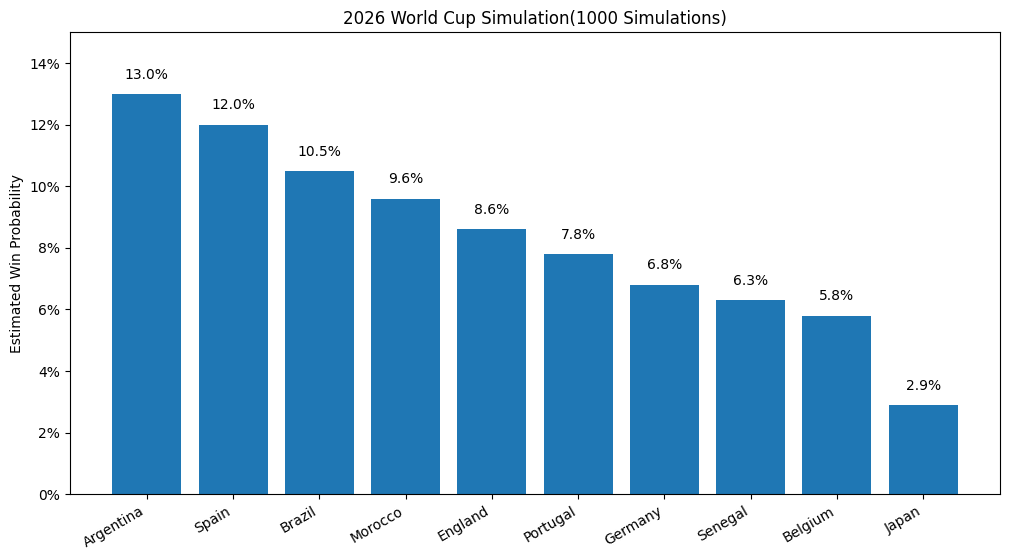

In [151]:
import matplotlib.pyplot as plt

df = pd.DataFrame(counts.items(), columns=["team", "wins"])
df["probability"] = df["wins"] / 1000
df = df.sort_values("wins", ascending=False)

print(df)
top10 = df.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["team"], top10["probability"])
plt.xticks(rotation=30, ha='right')
plt.ylabel("Estimated Win Probability")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
plt.title("2026 World Cup Simulation(1000 Simulations)")
plt.ylim(0, max(top10["probability"]) + 0.02)
for i, v in enumerate(top10["probability"]):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center')
plt.show()

Key takeaways:
- The model outperformed a baseline (~56% vs ~47%) but struggled with draws.  
- Simulation results highlight the uncertainty of tournament outcomes, even for top teams.  
- Time-aware data merging and feature engineering were critical to model performance.  
- Future improvements include additional features and alternative modeling approaches.